In [3]:
from uafgi.util import gdalutil,shapelyutil,shputil
import numpy as np
import matplotlib.pyplot as plt
import importlib
from dggs.avalanche import domain
%matplotlib inline

In [4]:
pras_file = '/Users/eafischer2/av/prj/juneau1/juneau1_For_5m_30L_rel.shp'
dem_file = '/Users/eafischer2/av/data/wolken/BaseData_AKAlbers/Juneau_IFSAR_DTM_AKAlbers_EPSG_3338.tif'

In [5]:
    grid_info,dem,dem_nodata = gdalutil.read_raster(dem_file)


In [6]:
grid_info

RasterInfo:
    x: [1105846.4870695253, 1155016.4870695253] dx=5.0 nx=9834
    y: [1114124.8755090903,1069214.8755090903] dy=-5.0 ny=8982
    geotransform: (1105846.4870695253, 5.0, 0.0, 1114124.8755090903, 0.0, -5.0)
    wkt: PROJCS["NAD_1983_Alaska_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",50],PARAMETER["longitude_of_center",-154],PARAMETER["standard_parallel_1",55],PARAMETER["standard_parallel_2",65],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3338"]]

In [16]:
    dem[dem==dem_nodata] = 0

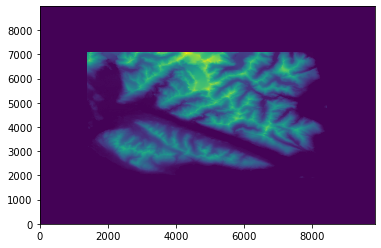

In [19]:
# flipud() because dem is North-up (standard for TIF files); whereas pcolormesh puts zero at the bottom
plt.pcolormesh(np.flipud(dem))

In [20]:
plt.show()

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [74]:
nj,ni = dem.shape
ivals = np.tile(np.arange(0,ni),(nj,1))
jvals = np.tile(np.arange(0,nj).reshape(-1,1), (1,ni))
ixvals = jvals * ni + ivals
ixvals

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]])

In [116]:
neighbors = np.zeros((dem.shape[0], dem.shape[1], 10))
neighbors.shape

(4, 10, 10)

In [117]:
ixvals[1:,:]

array([[10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]])

In [127]:
neighbors[:,:,NE]

array([[-1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., -1.],
       [11., 12., 13., 14., 15., 16., 17., 18., 19., -1.],
       [21., 22., 23., 24., 25., 26., 27., 28., 29., -1.]])

In [124]:
neighbors[:,:,9]

array([[11., 12., 13., 14., 15., 16., 17., 18., 19., -1.],
       [21., 22., 23., 24., 25., 26., 27., 28., 29., -1.],
       [31., 32., 33., 34., 35., 36., 37., 38., 39., -1.],
       [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1.]])

In [65]:
np.concatenate((np.zeros((nj,1)), ixvals[1:,:]), axis=0)

ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 10

In [49]:
ivals.shape

(8982, 9834)

In [50]:
jvals.shape

(8982, 9834)

In [52]:
jvals

array([[   0,    0,    0, ...,    0,    0,    0],
       [   1,    1,    1, ...,    1,    1,    1],
       [   2,    2,    2, ...,    2,    2,    2],
       ...,
       [8979, 8979, 8979, ..., 8979, 8979, 8979],
       [8980, 8980, 8980, ..., 8980, 8980, 8980],
       [8981, 8981, 8981, ..., 8981, 8981, 8981]])

In [128]:
a,b = (2,3)

In [129]:
a

2

In [130]:
b

3

In [171]:
def neighbor_array(raster, nodata):
    """Create an graph of nodes with adjoining nodes.
    The graph is represented as a 3D array of integers.

    raster: np.array(nj,ni); nj=# rows
        A raster
    nodata: scalar
        Value of cells in raster with missing data
    Returns: nparray((nj, ni, 9), dtype='i')
        1-D index of each of the 8 neighbors of each cell.
        
        neighbor[j,i,0] = index of cell (j,i)
            --> or -1 if no data in (j,i)
        neighbor[j,i,n] = nth neighbor of cell (j,i)
            --> or -1 if cell (j,i) has fewer than n neighbors
            Neighbors are sorted by their 1D index

        By definition, cells with neighbor[j,i,0] == -1 have zero
        neighbors; and thus, neighbor[j,i,1:] == -1 as well.
    """

    # Create 3D output array
    nj,ni = raster.shape
    neighbors = np.zeros((nj, ni, 9))

    # Create 2-D array giving 1-D index of each cell
    # ixvals = array([
    #   [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
    #   [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
    #   [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
    #   [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]])
    ivals = np.tile(np.arange(0,ni),(nj,1))
    jvals = np.tile(np.arange(0,nj).reshape(-1,1), (1,ni))
    neighbors[:,:,CC] = jvals * ni + ivals

    # Any cells with missing values, turn their 1-D index to -1 This
    # will result in a -1 as the appropriate index for neighbors with
    # missing values.
    ixvals = neighbors[:,:,CC]   # live slice
    ras_nodata = (raster == nodata)
    ixvals[ras_nodata] = -1

    # Compute neighbors NN and SS by shifting up/down
    izeros=np.zeros((1,ni), dtype='int64')-1
    neighbors[:,:,NN] = np.concatenate((izeros, ixvals[:-1,:]))
    neighbors[:,:,SS] = np.concatenate((ixvals[1:,:], izeros))

    # Compute neighbors WW and EE by shifting left/right
    jzeros=np.zeros((nj,1), dtype='int64')-1
    neighbors[:,:,WW] = np.concatenate((jzeros, ixvals[:,:-1]), axis=1)
    neighbors[:,:,EE] = np.concatenate((ixvals[:,1:], jzeros), axis=1)

    # Compute neighbors NW and SW by shifting WW up/down
    neighbors[:,:,NW] = np.concatenate((izeros, neighbors[:-1,:,WW]))
    neighbors[:,:,SW] = np.concatenate((neighbors[1:,:,WW], izeros))

    # Compute neighbors NE and SE by shifting EE up/down
    neighbors[:,:,NE] = np.concatenate((izeros, neighbors[:-1,:,EE]))
    neighbors[:,:,SE] = np.concatenate((neighbors[1:,:,EE], izeros))

    # Remove neighbors of non-existant cells
    neighbors[ras_nodata,:] = -1

    # Sort so neighbors[j,i,:] yields:
    #     [index, neighbor1, neighbor2, .., -1, -1,]
    ixvals = neighbors[:,:,0:1]
    sorted_neighbors = -np.sort(-neighbors[:,:,1:],axis=2)
    neighbors = np.concatenate((ixvals, sorted_neighbors), axis=2)

    return neighbors


In [172]:
# Small example
dem = np.zeros((4,10))
dem[0:3,0] = -5
dem[0:1,1] = -5
dem

array([[-5., -5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

In [173]:
ngh = neighbor_array(dem, -5.)
for i in range(0,9):
    print('************** neighbor = {}'.format(i))
    print(ngh[:,:,i])

************** neighbor = 0
[[-1. -1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [-1. 11. 12. 13. 14. 15. 16. 17. 18. 19.]
 [-1. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
 [30. 31. 32. 33. 34. 35. 36. 37. 38. 39.]]
************** neighbor = 1
[[-1. -1. 13. 14. 15. 16. 17. 18. 19. 19.]
 [-1. 22. 23. 24. 25. 26. 27. 28. 29. 29.]
 [-1. 32. 33. 34. 35. 36. 37. 38. 39. 39.]
 [31. 32. 33. 34. 35. 36. 37. 38. 39. 38.]]
************** neighbor = 2
[[-1. -1. 12. 13. 14. 15. 16. 17. 18. 18.]
 [-1. 21. 22. 23. 24. 25. 26. 27. 28. 28.]
 [-1. 31. 32. 33. 34. 35. 36. 37. 38. 38.]
 [21. 30. 31. 32. 33. 34. 35. 36. 37. 29.]]
************** neighbor = 3
[[-1. -1. 11. 12. 13. 14. 15. 16. 17.  8.]
 [-1. 12. 21. 22. 23. 24. 25. 26. 27. 18.]
 [-1. 30. 31. 32. 33. 34. 35. 36. 37. 28.]
 [-1. 22. 23. 24. 25. 26. 27. 28. 29. 28.]]
************** neighbor = 4
[[-1. -1.  3.  4.  5.  6.  7.  8.  9. -1.]
 [-1.  2. 13. 14. 15. 16. 17. 18. 19.  9.]
 [-1. 22. 23. 24. 25. 26. 27. 28. 29. 19.]
 [-1. 21. 22. 23. 24. 25. 26. 27. 28. -

In [174]:
print(ngh[-1,-2,:])

[38. 39. 37. 29. 28. 27. -1. -1. -1.]


In [175]:
dem1d = dem.reshape(-1)
dem1d

array([-5., -5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -5.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0., -5.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.])

In [7]:
from dggs.avalanche import domain
import importlib
importlib.reload(domain)

dem,nodata0=domain.dem_example()
nodata = 30.   # Something higher than other elevations, so nothing flows into it
dem[dem == nodata0] = nodata

dem1d = dem.reshape(-1)
unused_ix = np.where(dem1d==nodata)[0][0]

print(unused_ix)
dem

ValueError: too many values to unpack (expected 2)

In [309]:
ngh = neighbor_array(dem,nodata).astype('i')
# Set neighbor to an unused index (with a high elevation), so it will not be min neighbor
ngh[ngh == -1] = unused_ix
ngh[:,:,5]

array([[ 0,  0,  0,  0,  3,  4,  5,  6,  7,  0],
       [ 0,  0,  3, 12, 13, 14, 15, 16, 17,  8],
       [ 0,  0, 21, 22, 23, 24, 25, 26, 27, 18],
       [ 0, 22, 31, 32, 33, 34, 35, 36, 37, 28],
       [ 0, 40, 41, 42, 43, 44, 45, 46, 47, 38],
       [40, 50, 51, 52, 53, 54, 55, 56, 57, 48],
       [50, 60, 61, 62, 63, 64, 65, 66, 67, 58],
       [60, 70, 71, 72, 73, 74, 75, 76, 77, 68],
       [ 0, 70, 71, 72, 73, 74, 75, 76, 77,  0]], dtype=int32)

In [310]:
# nghelev: Elevation of each neighbor
nghelev = dem1d[ngh]
#nghelev

In [311]:
np.argmin(nghelev, axis=2)

array([[0, 0, 0, 3, 5, 5, 5, 5, 5, 3],
       [0, 0, 0, 5, 8, 8, 8, 8, 8, 5],
       [0, 4, 7, 8, 8, 8, 8, 8, 8, 5],
       [0, 6, 8, 8, 8, 8, 8, 8, 8, 5],
       [4, 7, 8, 8, 8, 8, 8, 8, 8, 5],
       [5, 8, 8, 8, 8, 8, 8, 8, 8, 5],
       [5, 8, 8, 8, 8, 8, 8, 8, 8, 5],
       [5, 8, 8, 8, 8, 8, 8, 8, 8, 5],
       [3, 5, 5, 5, 5, 5, 5, 5, 5, 3]])

In [312]:
# ixvals: Enumeration of 1-D index of each cell
nj=9
ni=10
ivals = np.tile(np.arange(0,ni),(nj,1))
jvals = np.tile(np.arange(0,nj).reshape(-1,1), (1,ni))
ixvals = jvals * ni + ivals
ixvals*9

array([[  0,   9,  18,  27,  36,  45,  54,  63,  72,  81],
       [ 90,  99, 108, 117, 126, 135, 144, 153, 162, 171],
       [180, 189, 198, 207, 216, 225, 234, 243, 252, 261],
       [270, 279, 288, 297, 306, 315, 324, 333, 342, 351],
       [360, 369, 378, 387, 396, 405, 414, 423, 432, 441],
       [450, 459, 468, 477, 486, 495, 504, 513, 522, 531],
       [540, 549, 558, 567, 576, 585, 594, 603, 612, 621],
       [630, 639, 648, 657, 666, 675, 684, 693, 702, 711],
       [720, 729, 738, 747, 756, 765, 774, 783, 792, 801]])

In [313]:
# nghflow: Single neighbor with lowest elevation.
ngh1d = ngh.reshape(-1)
# np.argmin(nghelev,axis=2) = axis-2-index (0-8) of minimum-elevation neighbor for each gridcell
# Add to ixvals*9 to get index of lowest neighbor in flattened (3d-to-1d) ngh
nghflow = ngh1d[ixvals*9 + np.argmin(nghelev,axis=2)]
nghflow1d = nghflow.reshape(-1)
nghflow

array([[ 0,  0,  0, 12,  3,  4,  5,  6,  7,  8],
       [ 0,  0, 12, 12,  3,  4,  5,  6,  7,  8],
       [ 0, 12, 12, 12, 13, 14, 15, 16, 17, 18],
       [ 0, 21, 21, 22, 23, 24, 25, 26, 27, 28],
       [31, 31, 31, 32, 33, 34, 35, 36, 37, 38],
       [40, 40, 41, 42, 43, 44, 45, 46, 47, 48],
       [50, 50, 51, 52, 53, 54, 55, 56, 57, 58],
       [60, 60, 61, 62, 63, 64, 65, 66, 67, 68],
       [70, 70, 71, 72, 73, 74, 75, 76, 77, 78]], dtype=int32)

In [335]:
# Start off with a rasterized polygon of the PRA
pra_ras = np.zeros((nj,ni), dtype='b')
pra_ras[7,8] = 1
pra_ras[6,8] = 1
pra_ras[2,9] = 1

pra_ras

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int8)

In [350]:
# Get a working set of indices
pra_ras1d = pra_ras.reshape(-1)
cur_ix = set(np.where(pra_ras1d)[0])
seen_ras = np.zeros(pra_ras.shape)
seen_ras1d = seen_ras.reshape(-1)
seen_ix = set()
print(seen_ix, cur_ix)

set() {68, 29, 78}


In [351]:
# Work down the gradient until we run out of indices
while True:
    # Iterate one step forward
    new_ix = cur_ix.difference(seen_ix)
    seen_ras1d[list(new_ix)] = 1
    seen_ix.update(new_ix)
    cur_ix = set(nghflow1d[list(cur_ix)]).difference(seen_ix)
    print(seen_ix, cur_ix)
    if len(cur_ix) == 0:
        break
print(seen_ras)

{68, 29, 78} {57, 18, 67}
{18, 67, 68, 57, 29, 78} {56, 46, 7}
{67, 68, 7, 78, 46, 18, 56, 57, 29} {35, 45, 6}
{67, 68, 35, 6, 7, 45, 78, 46, 18, 56, 57, 29} {24, 34, 5}
{34, 67, 68, 35, 6, 7, 5, 45, 78, 46, 18, 56, 57, 29, 24} {4, 13, 23}
{34, 67, 68, 35, 6, 7, 5, 4, 45, 78, 46, 13, 18, 23, 56, 57, 29, 24} {3, 12}
{67, 68, 5, 6, 7, 4, 3, 12, 13, 78, 18, 23, 24, 29, 34, 35, 45, 46, 56, 57} set()
[[0. 0. 0. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [361]:
seen_list = sorted(list(seen_ix))

# Convert to 2D indices
jvals1d = jvals.reshape(-1)
jj = jvals1d[seen_list]
ivals1d = ivals.reshape(-1)
ii = ivals1d[seen_list]
print(jj)
print(ii)

[0 0 0 0 0 1 1 1 2 2 2 3 3 4 4 5 5 6 6 7]
[3 4 5 6 7 2 3 8 3 4 9 4 5 5 6 6 7 7 8 8]


In [362]:
# Convert 2D indices to (x,y) point locations
# (center of gridcell)
#xx,yy = geo_info.to_xy(ii,jj)
xx = ii.astype('d')# DUMMY: Identity geotransform
yy = jj.astype('d')# DUMMY: Identity geotransform
print(xx)
print(yy)

[3. 4. 5. 6. 7. 2. 3. 8. 3. 4. 9. 4. 5. 5. 6. 6. 7. 7. 8. 8.]
[0. 0. 0. 0. 0. 1. 1. 1. 2. 2. 2. 3. 3. 4. 4. 5. 5. 6. 6. 7.]


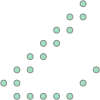

In [369]:
# Create a Shapely multipoint object from our (x,y) coordinates
# Should be shapely.geometry.
import shapely.geometry
#list(zip(xx,yy))
mp = shapely.geometry.MultiPoint(list(zip(xx,yy)))
mp

In [383]:
# Extract a convex hull polygon of our runout
chull = mp.convex_hull
print(chull.exterior.coords.xy)
chull_list = list(zip(*chull.exterior.coords.xy))
print(chull_list)

(array('d', [3.0, 2.0, 8.0, 9.0, 7.0, 3.0]), array('d', [0.0, 1.0, 7.0, 2.0, 0.0, 0.0]))
[(3.0, 0.0), (2.0, 1.0), (8.0, 7.0), (9.0, 2.0), (7.0, 0.0), (3.0, 0.0)]


In [375]:
# https://stackoverflow.com/questions/13542855/algorithm-to-find-the-minimum-area-rectangle-for-given-points-in-order-to-comput
#
# Use algorithm found online for minimum bounding rectangle
# https://stackoverflow.com/questions/13542855/algorithm-to-find-the-minimum-area-rectangle-for-given-points-in-order-to-comput
import scipy.spatial

In [389]:
# https://stackoverflow.com/questions/13542855/algorithm-to-find-the-minimum-area-rectangle-for-given-points-in-order-to-comput
def mostfar(hull, j, n, s, c, mx, my): # advance j to extreme point
    xn, yn = hull[j][0], hull[j][1]
    rx, ry = xn*c - yn*s, xn*s + yn*c
    best = mx*rx + my*ry
    while True:
        x, y = rx, ry
        xn, yn = hull[(j+1)%n][0], hull[(j+1)%n][1]
        rx, ry = xn*c - yn*s, xn*s + yn*c
        if mx*rx + my*ry >= best:
            j = (j+1)%n
            best = mx*rx + my*ry
        else:
            return (x, y, j)

In [393]:
import math
# hull = [(23.45, 57.39), (23.45, 60.39), (24.45, 63.39),
#        (26.95, 68.39), (28.45, 69.89), (34.95, 71.89),
#        (36.45, 71.89), (37.45, 70.39), (37.45, 64.89),
#        (36.45, 63.39), (34.95, 61.39), (26.95, 57.89),
#        (25.45, 57.39), (23.45, 57.39)]
        
def min_rect(hull):
    n = len(hull)
    iL = iR = iP = 1                # indexes left, right, opposite
    pi = 4*math.atan(1)
    for i in range(n-1):
        dx = hull[i+1][0] - hull[i][0]
        dy = hull[i+1][1] - hull[i][1]
        theta = pi-math.atan2(dy, dx)
        s, c = math.sin(theta), math.cos(theta)
        yC = hull[i][0]*s + hull[i][1]*c

        xP, yP, iP = mostfar(hull, iP, n, s, c, 0, 1)
        if i==0: iR = iP
        xR, yR, iR = mostfar(hull, iR, n, s, c,  1, 0)
        xL, yL, iL = mostfar(hull, iL, n, s, c, -1, 0)
        area = (yP-yC)*(xR-xL)

    print('    {:2d} {:2d} {:2d} {:2d} {:9.3f}'.format(i, iL, iP, iR, area))
    return i,iL,iP,iR,area

In [400]:
print(chull_list)
# Last point needs to be same as first
i,iL,iP,iR,area = min_rect(chull_list)

[(3.0, 0.0), (2.0, 1.0), (8.0, 7.0), (9.0, 2.0), (7.0, 0.0), (3.0, 0.0)]
     4  1  2  3    49.000


[4, 1, 2, 3]
[(3.0, 0.0), (2.0, 1.0), (8.0, 7.0), (9.0, 2.0), (7.0, 0.0), (3.0, 0.0)]


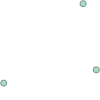

In [407]:
print([i,iL,iP,iR])
print(chull_list)
rec_points = [chull_list[x] for x in [iL,iP,iR]]
shapely.geometry.MultiPoint(rec_points)

In [413]:
import MinimumBoundingBox
print(chull_list)
mbb = MinimumBoundingBox.MinimumBoundingBox(chull_list[:-1])
mbb

[(3.0, 0.0), (2.0, 1.0), (8.0, 7.0), (9.0, 2.0), (7.0, 0.0), (3.0, 0.0)]


BoundingBox(area=36.0, length_parallel=4.242640687119286, length_orthogonal=8.48528137423857, rectangle_center=(6.5, 2.499999999999999), unit_vector=(0.7071067811865475, -0.7071067811865475), unit_vector_angle=-0.7853981633974483, corner_points={(5.0, -2.0), (2.0, 0.9999999999999989), (11.0, 4.0), (8.0, 6.999999999999999)})

In [414]:
mbb.corner_points

{(2.0, 0.9999999999999989), (5.0, -2.0), (8.0, 6.999999999999999), (11.0, 4.0)}

In [423]:
mbb_rectangle=shapely.geometry.MultiPoint(list(mbb.corner_points)).convex_hull
mbb_rectangle.plot()

AttributeError: 'Polygon' object has no attribute 'plot'

[array([ 5., -2.]), array([2., 1.]), array([8., 7.]), array([11.,  4.]), array([ 5., -2.])]


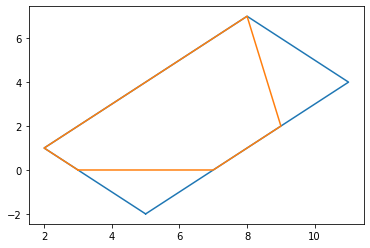

In [435]:
# mbb_rectangle is our domain!!!
plt.plot(*mbb_rectangle.exterior.xy)
plt.plot(*chull.exterior.xy)
mbb_points = list(np.array(xy) for xy in zip(*mbb_rectangle.exterior.xy))
print(mbb_points)

In [462]:
# Get "basis vectors" of rectangle
v0 = mbb_points[1] - mbb_points[0]
v1 = mbb_points[-2] - mbb_points[0]
print(v0)
print(v1)

v0 = np.array(mbb.unit_vector)
v1 = np.array([-mbb.unit_vector[1], mbb.unit_vector[0]])  # Rotate clockwise 90-degrees
#v0 = np.zeros(2)
#v1 = v0
print(v0)
print(v1)



[-3.  3.]
[6. 6.]
[ 0.70710678 -0.70710678]
[0.70710678 0.70710678]


In [479]:
# Make a bigger rectangle
margin = 1.
#print(mbb_points)
bigger_points = [mbb_points[0]+v0-v1, mbb_points[1]-v0-v1, mbb_points[2]-v0+v1, mbb_points[3]+v0+v1, mbb_points[4]+v0-v1]
bigger = shapely.geometry.Polygon(bigger_points)
bigger.exterior.xy
#bigger_points = [list(x) for x in bigger_points]
#print(bigger_points)

(array('d', [5.0, 0.5857864376269051, 8.0, 12.414213562373096, 5.0]),
 array('d', [-3.414213562373095, 0.9999999999999989, 8.414213562373094, 4.0, -3.414213562373095]))

(array('d', [5.0, 2.0, 8.0, 11.0, 5.0]), array('d', [-2.0, 0.9999999999999989, 6.999999999999999, 4.0, -2.0]))


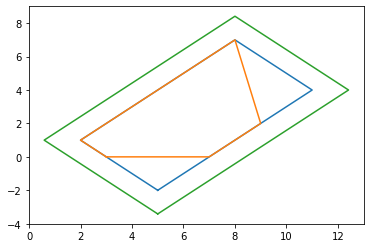

In [480]:
plt.plot(*mbb_rectangle.exterior.xy)
print(mbb_rectangle.exterior.xy)
plt.plot(*chull.exterior.xy)
plt.plot(*bigger.exterior.xy)

In [ ]:
# TODO: Unit vectors are confused!

In [8]:
# =============================================================
# ==============================================================
# =======================================
pras_file = '/Users/eafischer2/av/prj/juneau1/juneau1_For_5m_30L_rel.shp'
dem_file = '/Users/eafischer2/av/data/wolken/BaseData_AKAlbers/Juneau_IFSAR_DTM_AKAlbers_EPSG_3338.tif'

# Read DEM
#grid_info,dem,dem_nodata = gdalutil.read_raster(dem_file)
grid_info,dem,dem_nodata = domain.dem_example()


# Read (one) polygon
pras_df = shputil.read_df(pras_file)
row = pras_df.iloc[0]
print(row)
pra = row['shape']
#print('*** ',pra)
pra_ds = shapelyutil.to_datasource(pra)
pra_ras = gdalutil.rasterize_polygons(pra_ds, grid_info)




area_m2                                                 74900.0
Mean_DEM                                             642.224231
Mean_Slope                                            44.611567
Scene_reso                                                  5.0
fid                                                           0
sx3                                                   61.494141
d0star                                                54.774859
slopecorr                                              0.270554
Wind                                                        0.0
d0_30                                                 14.819563
VOL_30                                           1559221.537805
shape         POLYGON ((1141096.4870695253 1086984.875509090...
Name: 0, dtype: object


In [5]:
# Get list of indices of cells in the PRA
cells0=np.where(pra_ras.reshape(-1))[0]


In [6]:
%%time
importlib.reload(domain)
#dem,nodata0,grid_info=domain.dem_example()
nj,ni = dem.shape

print('AA1')
neighbors = domain.neighbor_array(dem,dem_nodata)
print('AA2')
ecg = domain.ECGraph(neighbors)
print('AA3')
domain.fill_sinks(ecg, dem)
print('AA4')
domain.set_lowest_neighbor(ecg,dem)
#cells0 = {78,68,29}

AA1
AA2
BB1
Found 7 unused cells
BB2
BB3
BB4
BB5
AA3
Merging 45 -> 44
Merging 54 -> 44
Merging 55 -> 44
Merging 33 -> 44
AA4
CPU times: user 6.19 ms, sys: 2.57 ms, total: 8.76 ms
Wall time: 8.34 ms


In [7]:
import pickle
with open('ecg.pim', 'wb') as out:
    pickle.dump(ecg, out)

In [711]:
print('AA5')
cells1 = domain.fill_region(ecg, cells0)

ivals = np.tile(np.arange(0,ni),(nj,1)).reshape(-1)
jvals = np.tile(np.arange(0,nj).reshape(-1,1), (1,ni)).reshape(-1)
ii = ivals[cells1]
jj = jvals[cells1]

xx,yy = grid_info.to_xy(ii,jj)
print(yy)
print(xx)

AA1
AA2
BB1
Found 0 unused cells
BB2


KeyboardInterrupt: 

In [682]:
import MinimumBoundingBox
mp = shapely.geometry.MultiPoint(list(zip(xx,yy)))
chull = mp.convex_hull
chull_list = list(zip(*chull.exterior.coords.xy))
mbb = MinimumBoundingBox.MinimumBoundingBox(chull_list[:-1])

margin = 2
center = np.array(list(mbb.rectangle_center))
j0 = np.array(list(mbb.unit_vector))
jj0 = j0 * (margin + .5*mbb.length_parallel)
j1 = np.array([j0[1],-j0[0]])
jj1 = j1 * (margin + .5*mbb.length_orthogonal)
mbb_points = [center+jj0+jj1, center+jj0-jj1,  center-jj0+jj1, center-jj0-jj1]
mbb_rectangle = shapely.geometry.MultiPoint(list(mbb_points)).convex_hull

#mbb_rectangle=shapely.geometry.MultiPoint(list(mbb.corner_points)).convex_hull
mbb


BoundingBox(area=191.99999999999997, length_parallel=11.31370849898476, length_orthogonal=16.97056274847714, rectangle_center=(12.0, 5.999999999999998), unit_vector=(0.7071067811865475, -0.7071067811865475), unit_vector_angle=-0.7853981633974483, corner_points={(2.0000000000000018, 3.999999999999996), (10.0, -4.0), (14.000000000000002, 15.999999999999996), (22.0, 7.999999999999998)})

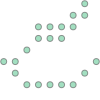

In [683]:
mp

[array([10.        , -6.82842712]), array([-0.82842712,  4.        ]), array([14.        , 18.82842712]), array([24.82842712,  8.        ]), array([10.        , -6.82842712])]


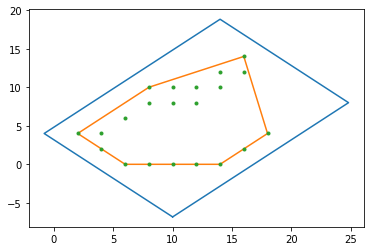

In [684]:
# mbb_rectangle is our domain!!!
plt.plot(*mbb_rectangle.exterior.xy)
plt.plot(*chull.exterior.xy)
plt.plot(xx,yy,marker='.', linewidth=0)
mbb_points = list(np.array(xy) for xy in zip(*mbb_rectangle.exterior.xy))
print(mbb_points)


In [1]:
import d8graph

In [2]:
dem

NameError: name 'dem' is not defined

In [9]:
dem

array([[-5. , -5. , -5. ,  7.4,  8.8, 10.2, 11.6, 13. , 14.4, 15.8],
       [-5. , -5. ,  6.6,  8. ,  9.4, 10.8, 12.2, 13.6, 15. , 16.4],
       [-5. ,  7. ,  7.6,  8.6, 10. , 11.4, 12.8, 14.2, 15.6, 17. ],
       [-5. ,  8.4,  9. ,  9.6, 10.6, 12. , 13.4, 14.8, 16.2, 17.6],
       [ 9.2,  9.8, 10.4, 11. ,  6. ,  6. , 14. , 15.4, 16.8, 18.2],
       [10.6, 11.2, 11.8, 12.4,  6. ,  6. , 14.6, 16. , 17.4, 18.8],
       [12. , 12.6, 13.2, 13.8, 14.4, 15. , 15.6, 16.6, 18. , 19.4],
       [13.4, 14. , 14.6, 15.2, 15.8, 16.4, 17. , 17.6, 18.6, 20. ],
       [14.8, 15.4, 16. , 16.6, 17.2, 17.8, 18.4, 19. , 19.6, 20.6]])

In [ ]:
d8graph.neighbor_graph(dem, dem_nodata, 2)